## 1. Install & Import Libraries

In [3]:
import warnings

# Sembunyikan warning
warnings.filterwarnings("ignore")

# Install dependencies
!pip install mlxtend openpyxl plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Association Rules
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Export
import pickle, joblib, os

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Libraries loaded


## 2. Load Dataset

In [4]:
# Load data
df = pd.read_excel('Online Retail.xlsx', engine='openpyxl')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Exploratory Data Analysis (EDA)

In [5]:
# 3.1 Overview
print('='*50)
print('DATASET OVERVIEW')
print('='*50)
print(f'Total rows       : {len(df):,}')
print(f'Unique invoices  : {df["InvoiceNo"].nunique():,}')
print(f'Unique products  : {df["StockCode"].nunique():,}')
print(f'Unique customers : {df["CustomerID"].nunique():,}')
print(f'Countries        : {df["Country"].nunique()}')
print(f'Date range       : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print()
print('Missing values:')
print(df.isnull().sum())
print()
print(df.describe())

DATASET OVERVIEW
Total rows       : 541,909
Unique invoices  : 25,900
Unique products  : 4,070
Unique customers : 4,372
Countries        : 38
Date range       : 2010-12-01 → 2011-12-09

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            

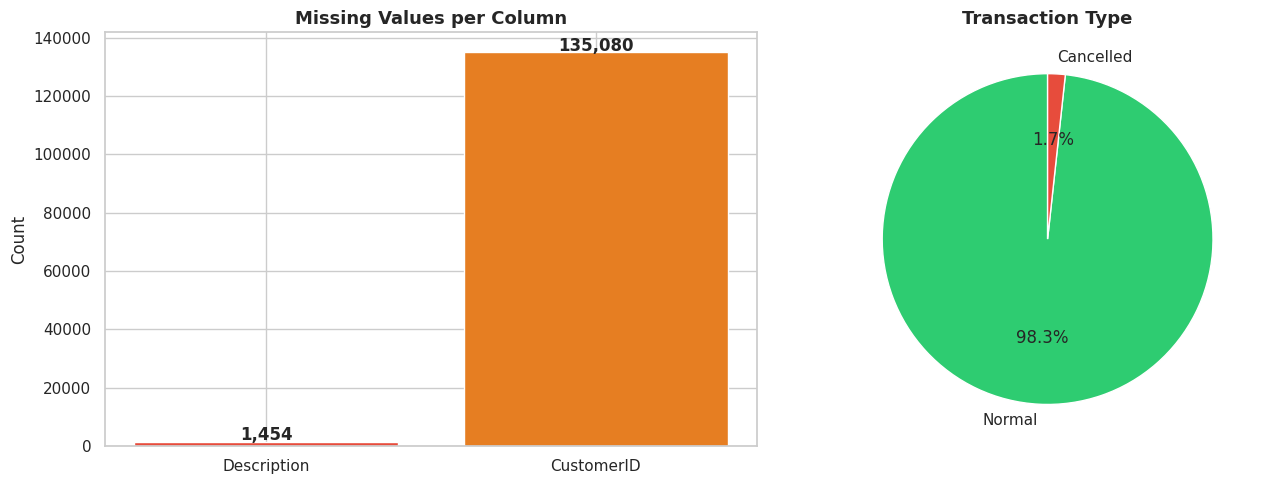

In [6]:
# 3.2 Missing Value Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
axes[0].bar(missing.index, missing.values, color=['#e74c3c', '#e67e22'])
axes[0].set_title('Missing Values per Column', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(missing.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Cancelled vs Normal
cancelled_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()
normal_count = len(df) - cancelled_count
axes[1].pie([normal_count, cancelled_count],
            labels=['Normal', 'Cancelled'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Transaction Type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# 3.3 Top Countries
top_countries = df['Country'].value_counts().head(10)
fig = px.bar(x=top_countries.values, y=top_countries.index,
             orientation='h',
             title='Top 10 Countries by Transaction Volume',
             labels={'x': 'Transactions', 'y': 'Country'},
             color=top_countries.values,
             color_continuous_scale='Blues')
fig.update_layout(showlegend=False, height=400)
fig.show()

In [8]:
# 3.4 Sales over Time
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly = df.groupby('YearMonth').agg(
    Revenue=('UnitPrice', lambda x: (x * df.loc[x.index, 'Quantity']).sum()),
    Transactions=('InvoiceNo', 'nunique')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=monthly['YearMonth'], y=monthly['Revenue'],
                     name='Revenue', marker_color='steelblue'), secondary_y=False)
fig.add_trace(go.Scatter(x=monthly['YearMonth'], y=monthly['Transactions'],
                          name='Transactions', line=dict(color='orange', width=2)),
              secondary_y=True)
fig.update_layout(title='Monthly Revenue & Transaction Volume', height=400)
fig.show()

In [9]:
# 3.5 Top Products
top_products = df.groupby('Description')['Quantity'].sum().nlargest(15)
fig = px.bar(x=top_products.values, y=top_products.index,
             orientation='h',
             title='Top 15 Products by Quantity Sold',
             labels={'x': 'Total Quantity', 'y': 'Product'},
             color=top_products.values,
             color_continuous_scale='Greens')
fig.update_layout(height=500, showlegend=False)
fig.show()

## 4. Data Cleaning & Preprocessing

In [10]:
# 4.1 Cleaning Rules
print('Before cleaning:', df.shape)

df_clean = df.copy()

# Hapus transaksi cancelled (InvoiceNo dimulai 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After remove cancelled: {df_clean.shape}')

# Hapus Quantity <= 0
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f'After remove Quantity<=0: {df_clean.shape}')

# Hapus UnitPrice <= 0
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f'After remove UnitPrice<=0: {df_clean.shape}')

# Hapus rows tanpa CustomerID (untuk clustering; ARM pakai semua)
df_rfm = df_clean[df_clean['CustomerID'].notna()].copy()
print(f'After remove missing CustomerID: {df_rfm.shape}')

# Tambah TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_rfm['TotalPrice']   = df_rfm['Quantity']   * df_rfm['UnitPrice']

print('\nCleaning selesai')
print(f'Dataset ARM (tanpa CustomerID filter): {df_clean.shape}')
print(f'Dataset RFM/Clustering               : {df_rfm.shape}')

Before cleaning: (541909, 9)
After remove cancelled: (532621, 9)
After remove Quantity<=0: (531285, 9)
After remove UnitPrice<=0: (530104, 9)
After remove missing CustomerID: (397884, 9)

Cleaning selesai
Dataset ARM (tanpa CustomerID filter): (530104, 10)
Dataset RFM/Clustering               : (397884, 10)


## 5. RFM Feature Engineering

In [11]:
# 5.1 Hitung RFM
snapshot_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_rfm.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print('RFM shape:', rfm.shape)
rfm.describe().round(2)

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


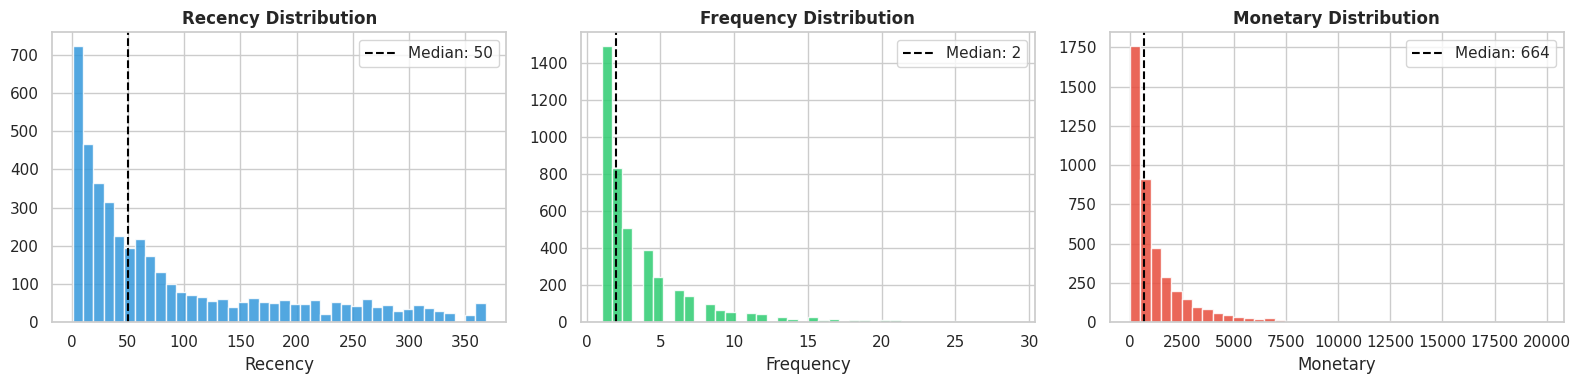

In [12]:
# 5.2 RFM Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'],
                           ['#3498db', '#2ecc71', '#e74c3c']):
    data = rfm[rfm[col] < rfm[col].quantile(0.99)][col]  # remove extreme outliers for viz
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.axvline(data.median(), color='black', linestyle='--', label=f'Median: {data.median():.0f}')
    ax.legend()
plt.tight_layout()
plt.savefig('rfm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 5.3 Log Transform + Scaling
rfm_log = rfm.copy()
rfm_log['Recency_log']   = np.log1p(rfm['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary_log']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['R_scaled', 'F_scaled', 'M_scaled'])

print('Scaled shape:', rfm_scaled_df.shape)
rfm_scaled_df.describe().round(3)

Scaled shape: (4338, 3)


,R_scaled,F_scaled,M_scaled
count,4338.000,4338.000,4338.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-4.005
25%,-0.661,-0.955,-0.686
50%,0.090,-0.362,-0.062
75%,0.845,0.653,0.654
max,1.564,5.859,4.732


## 6. K-Means Clustering — Segmentasi Pelanggan

In [14]:
# 6.1 Elbow Method + Silhouette
K_range = range(2, 11)
inertia_list, silhouette_list, db_list = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(rfm_scaled, labels))
    db_list.append(davies_bouldin_score(rfm_scaled, labels))
    print(f'k={k}: Inertia={km.inertia_:.0f}, Silhouette={silhouette_score(rfm_scaled,labels):.4f}, DB={davies_bouldin_score(rfm_scaled,labels):.4f}')

k=2: Inertia=6481, Silhouette=0.4329, DB=0.8921
k=3: Inertia=4868, Silhouette=0.3365, DB=1.0480
k=4: Inertia=3939, Silhouette=0.3371, DB=1.0101
k=5: Inertia=3296, Silhouette=0.3161, DB=0.9895
k=6: Inertia=2855, Silhouette=0.3133, DB=1.0134
k=7: Inertia=2549, Silhouette=0.3100, DB=0.9726
k=8: Inertia=2337, Silhouette=0.3008, DB=0.9940
k=9: Inertia=2156, Silhouette=0.2817, DB=1.0147
k=10: Inertia=2000, Silhouette=0.2787, DB=1.0202


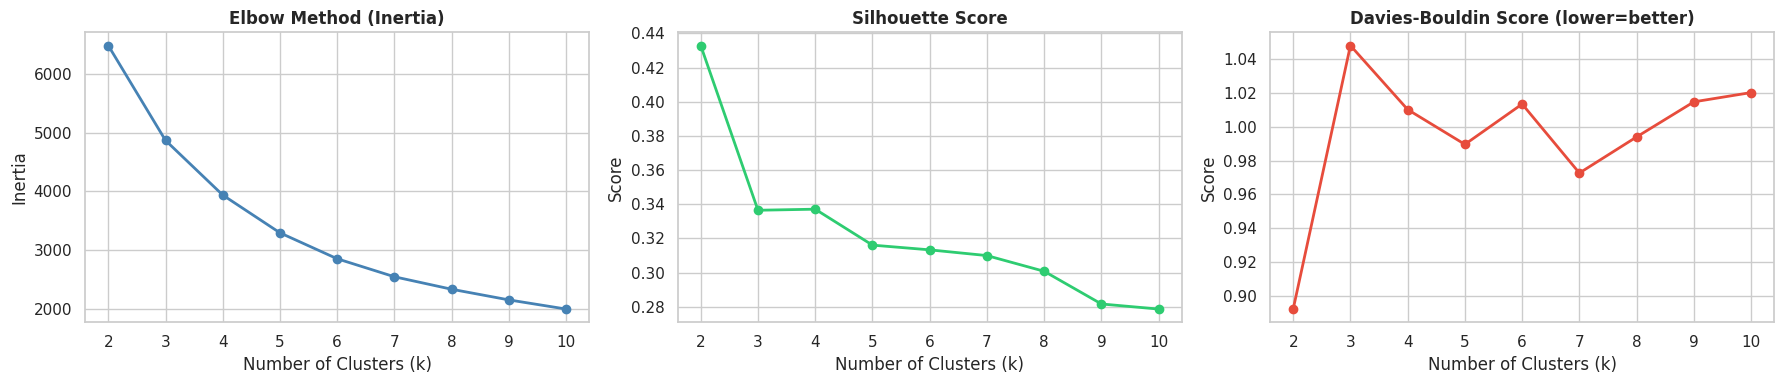

In [15]:
# 6.2 Plot Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(list(K_range), inertia_list, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouette_list, 'o-', color='#2ecc71', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

axes[2].plot(list(K_range), db_list, 'o-', color='#e74c3c', linewidth=2)
axes[2].set_title('Davies-Bouldin Score (lower=better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('cluster_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# 6.3 Final Clustering (k=4)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'Cluster distribution:')
print(rfm['Cluster'].value_counts().sort_index())
print(f'\nSilhouette Score: {silhouette_score(rfm_scaled, rfm["Cluster"]):.4f}')

Cluster distribution:
Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64

Silhouette Score: 0.3371


In [17]:
# 6.4 Cluster Profile
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profile['Count'] = rfm.groupby('Cluster').size()
cluster_profile['Pct'] = (cluster_profile['Count'] / len(rfm) * 100).round(1)
print(cluster_profile)

# Auto-labeling berdasarkan Recency rendah + Frequency & Monetary tinggi = Champion
def label_cluster(row):
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if r < 30 and f >= 5 and m >= 1000:
        return 'Champions'
    elif r < 60 and f >= 3:
        return 'Loyal Customers'
    elif r < 90 and f < 3:
        return 'Potential Loyalists'
    else:
        return 'At-Risk / Churned'

cluster_labels = cluster_profile[['Recency','Frequency','Monetary']].apply(label_cluster, axis=1)
cluster_profile['Label'] = cluster_labels
print('\nCluster Labels:')
print(cluster_profile[['Label','Count','Pct']])

rfm['ClusterLabel'] = rfm['Cluster'].map(cluster_labels)

         Recency  Frequency  Monetary  Count   Pct
Cluster                                           
0          18.12       2.15    551.82    837  19.3
1          12.13      13.71   8074.27    716  16.5
2          71.08       4.08   1802.83   1173  27.0
3         182.50       1.32    343.45   1612  37.2

Cluster Labels:
                       Label  Count   Pct
Cluster                                  
0        Potential Loyalists    837  19.3
1                  Champions    716  16.5
2          At-Risk / Churned   1173  27.0
3          At-Risk / Churned   1612  37.2


In [18]:
# 6.5 Visualisasi Cluster
# Radar Chart per cluster
from matplotlib.patches import FancyArrowPatch
import matplotlib.colors as mcolors

# PCA 2D
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = pca_coords[:, 0]
rfm['PCA2'] = pca_coords[:, 1]

fig = px.scatter(rfm, x='PCA1', y='PCA2', color='ClusterLabel',
                 hover_data=['Recency','Frequency','Monetary'],
                 title='Customer Segments (PCA 2D)',
                 color_discrete_sequence=px.colors.qualitative.Set2,
                 opacity=0.7)
fig.update_traces(marker=dict(size=5))
fig.show()

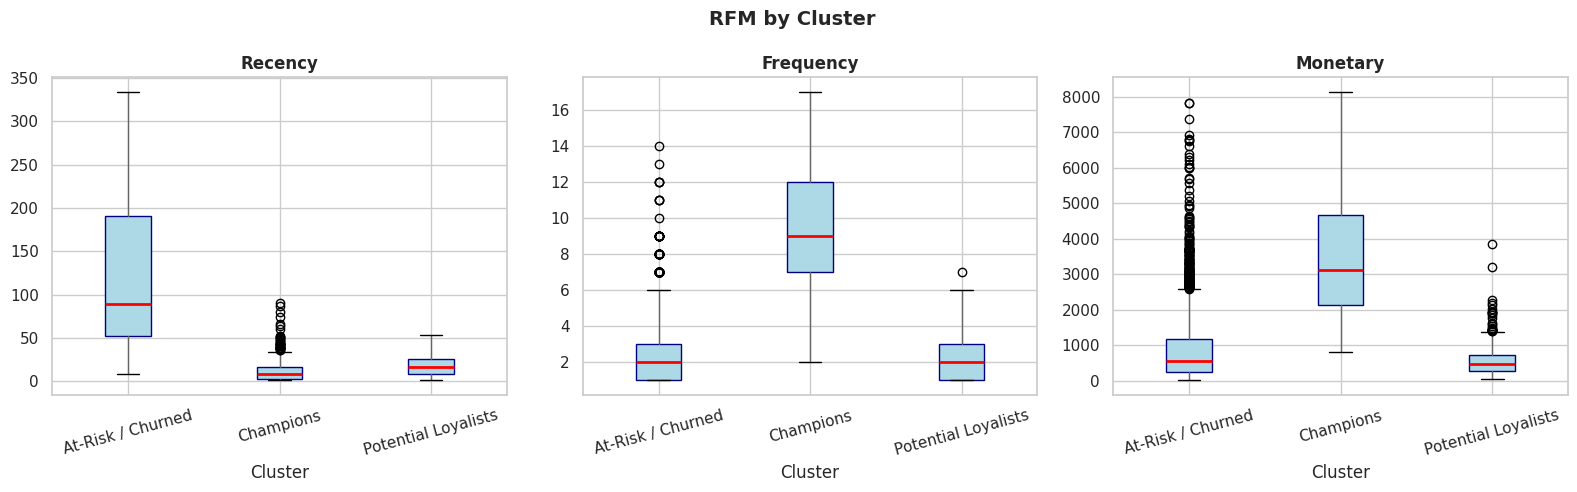

In [19]:
# Boxplot RFM per Cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    rfm_plot = rfm[rfm[col] < rfm[col].quantile(0.97)]
    rfm_plot.boxplot(column=col, by='ClusterLabel', ax=ax,
                     patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='navy'),
                     medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Cluster')
    plt.sca(ax)
    plt.xticks(rotation=15)
plt.suptitle('RFM by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Association Rule Mining (FP-Growth)

In [20]:
# 7.1 Prepare Basket Matrix
# Fokus UK, bisa diubah ke semua negara
country = 'United Kingdom'
df_arm = df_clean[df_clean['Country'] == country].copy()
print(f'Transaksi {country}: {len(df_arm):,}')

# Buat basket: setiap invoice sebagai 1 transaksi
basket = df_arm.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Encode: 1 jika beli, 0 jika tidak
basket_encoded = (basket > 0).astype(bool)
print(f'Basket matrix shape: {basket_encoded.shape}')
print(f'Density: {basket_encoded.sum().sum() / basket_encoded.size:.4f}')

Transaksi United Kingdom: 485,123
Basket matrix shape: (18019, 4007)
Density: 0.0066


In [21]:
# 7.2 FP-Growth
MIN_SUPPORT    = 0.02   # item muncul di >= 2% transaksi
MIN_CONFIDENCE = 0.3
MIN_LIFT       = 1.0

print('Running FP-Growth...')
frequent_itemsets = fpgrowth(basket_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f'Frequent itemsets: {len(frequent_itemsets)}')
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Running FP-Growth...
Frequent itemsets: 400
      support                              itemsets  length
0    0.119984  (WHITE HANGING HEART T-LIGHT HOLDER)       1
58   0.107387             (JUMBO BAG RED RETROSPOT)       1
159  0.093512            (REGENCY CAKESTAND 3 TIER)       1
238  0.088407                       (PARTY BUNTING)       1
19   0.077252             (LUNCH BAG RED RETROSPOT)       1
4    0.076086       (ASSORTED COLOUR BIRD ORNAMENT)       1
249  0.068872   (SET OF 3 CAKE TINS PANTRY DESIGN )       1
48   0.067651     (NATURAL SLATE HEART CHALKBOARD )       1
98   0.067484             (LUNCH BAG  BLACK SKULL.)       1
49   0.064598               (HEART OF WICKER SMALL)       1


In [22]:
# 7.3 Generate Rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=MIN_LIFT)
rules = rules[rules['confidence'] >= MIN_CONFIDENCE].sort_values('lift', ascending=False)

print(f'Total rules: {len(rules)}')
print('\nTop 10 rules by Lift:')
rules[['antecedents','consequents','support','confidence','lift']].head(10)

Total rules: 184

Top 10 rules by Lift:


,antecedents,consequents,support,confidence,lift
167,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.020423,0.722986,27.197263
166,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.020423,0.768267,27.197263
178,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.027305,0.702857,18.041001
183,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.027305,0.700855,18.041001
182,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.027305,0.527897,17.453534
179,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.027305,0.902752,17.453534
180,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.027305,0.854167,16.099612
181,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.027305,0.514644,16.099612
175,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031966,0.820513,15.863541
174,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031966,0.618026,15.863541


In [23]:
# 7.4 Visualisasi Rules
fig = px.scatter(rules, x='support', y='confidence',
                 size='lift', color='lift',
                 color_continuous_scale='RdYlGn',
                 title='Association Rules: Support vs Confidence (size=Lift)',
                 labels={'support':'Support', 'confidence':'Confidence'},
                 hover_data=['lift'])
fig.update_layout(height=500)
fig.show()

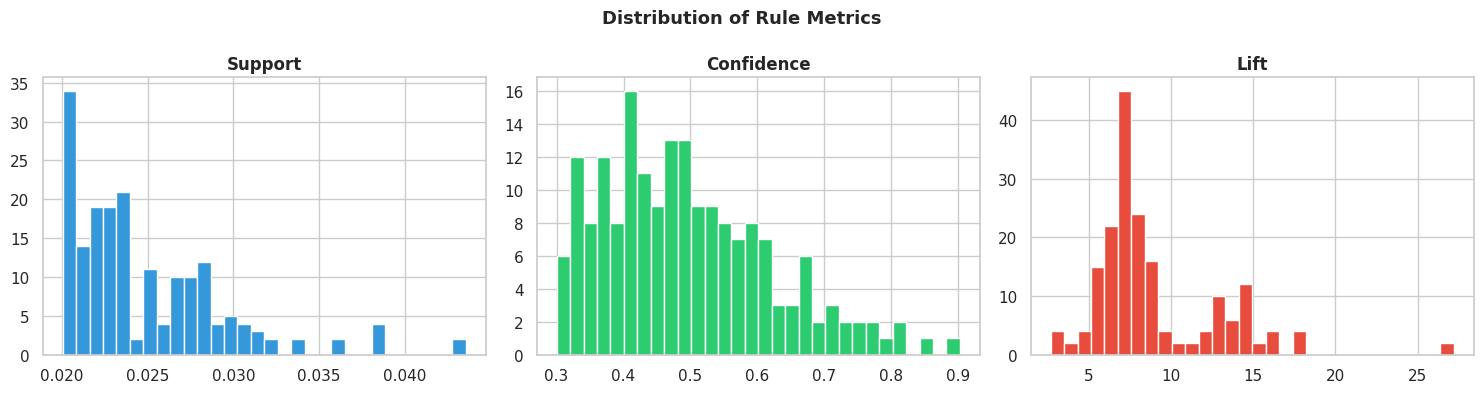

In [24]:
# 7.5 Rule Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['support','confidence','lift'],
                           ['#3498db','#2ecc71','#e74c3c']):
    axes[['support','confidence','lift'].index(col)].hist(rules[col], bins=30,
                                                           color=color, edgecolor='white')
    ax.set_title(col.capitalize(), fontweight='bold')
plt.suptitle('Distribution of Rule Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rules_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Rule-Based Recommendation Test

In [25]:
def get_recommendations(purchased_items, rules_df, top_n=5):
    """
    Berikan rekomendasi produk berdasarkan item yang sudah dibeli.
    """
    purchased_set = set(purchased_items)
    recommendations = {}

    for _, row in rules_df.iterrows():
        antecedent = set(row['antecedents'])
        consequent = set(row['consequents'])
        # Jika semua antecedent ada di cart
        if antecedent.issubset(purchased_set):
            for item in consequent:
                if item not in purchased_set:
                    if item not in recommendations or recommendations[item]['lift'] < row['lift']:
                        recommendations[item] = {
                            'lift': row['lift'],
                            'confidence': row['confidence'],
                            'support': row['support']
                        }

    result = pd.DataFrame(recommendations).T.sort_values('lift', ascending=False).head(top_n)
    return result

# Test
sample_items = list(frequent_itemsets[frequent_itemsets['length']==1]
                    .sort_values('support', ascending=False)['itemsets'].head(3))
sample_items = [list(s)[0] for s in sample_items]
print(f'Test dengan item: {sample_items}')
recs = get_recommendations(sample_items, rules)
print(recs)

Test dengan item: ['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'REGENCY CAKESTAND 3 TIER']
                                       lift  confidence   support
JUMBO BAG PINK POLKADOT            6.307190    0.405685  0.043565
JUMBO STORAGE BAG SUKI             5.752104    0.360724  0.038737
JUMBO SHOPPER VINTAGE RED PAISLEY  5.399893    0.339535  0.036462


## 9. Export Artifacts untuk Streamlit

In [26]:
import os
os.makedirs('streamlit_artifacts', exist_ok=True)

# 1. KMeans model + scaler
joblib.dump(kmeans,  'streamlit_artifacts/kmeans_model.pkl')
joblib.dump(scaler,  'streamlit_artifacts/scaler.pkl')
joblib.dump(pca,     'streamlit_artifacts/pca_model.pkl')
print(' Saved: kmeans_model.pkl, scaler.pkl, pca_model.pkl')

# 2. RFM data + cluster labels
rfm.to_csv('streamlit_artifacts/rfm_clustered.csv', index=False)
print(' Saved: rfm_clustered.csv')

# 3. Association Rules
rules_export = rules.copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: list(x))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: list(x))
rules_export.to_csv('streamlit_artifacts/association_rules.csv', index=False)
print(' Saved: association_rules.csv')

# 4. Frequent itemsets
fi_export = frequent_itemsets.copy()
fi_export['itemsets'] = fi_export['itemsets'].apply(lambda x: list(x))
fi_export.to_csv('streamlit_artifacts/frequent_itemsets.csv', index=False)
print(' Saved: frequent_itemsets.csv')

# 5. Clean dataset summary
df_rfm.to_csv('streamlit_artifacts/transactions_clean.csv', index=False)
print(' Saved: transactions_clean.csv')

# 6. Cluster profile
cluster_profile.reset_index().to_csv('streamlit_artifacts/cluster_profile.csv', index=False)
print(' Saved: cluster_profile.csv')

print('\n Semua artifacts tersimpan di folder: streamlit_artifacts/')

 Saved: kmeans_model.pkl, scaler.pkl, pca_model.pkl
 Saved: rfm_clustered.csv
 Saved: association_rules.csv
 Saved: frequent_itemsets.csv
 Saved: transactions_clean.csv
 Saved: cluster_profile.csv

 Semua artifacts tersimpan di folder: streamlit_artifacts/


In [27]:
# ---- Summary Final ----
print('='*60)
print('         SUMMARY ANALISIS POLA BELANJA')
print('='*60)
print(f'Dataset  : Online Retail UCI')
print(f'Period   : {df_rfm["InvoiceDate"].min().date()} → {df_rfm["InvoiceDate"].max().date()}')
print()
print('--- CLUSTERING ---')
print(f'Customers   : {len(rfm):,}')
print(f'Clusters    : {OPTIMAL_K}')
print(f'Silhouette  : {silhouette_score(rfm_scaled, rfm["Cluster"]):.4f}')
for cl, row in cluster_profile.iterrows():
    print(f'  Cluster {cl} [{row["Label"]}]: {int(row["Count"])} customers ({row["Pct"]}%)')
print()
print('--- ASSOCIATION RULES ---')
print(f'Frequent itemsets : {len(frequent_itemsets)}')
print(f'Rules generated   : {len(rules)}')
print(f'Avg Lift          : {rules["lift"].mean():.4f}')
print(f'Max Lift          : {rules["lift"].max():.4f}')
print('='*60)
print('✅ Notebook selesai. Siap deploy Streamlit!')

         SUMMARY ANALISIS POLA BELANJA
Dataset  : Online Retail UCI
Period   : 2010-12-01 → 2011-12-09

--- CLUSTERING ---
Customers   : 4,338
Clusters    : 4
Silhouette  : 0.3371
  Cluster 0 [Potential Loyalists]: 837 customers (19.3%)
  Cluster 1 [Champions]: 716 customers (16.5%)
  Cluster 2 [At-Risk / Churned]: 1173 customers (27.0%)
  Cluster 3 [At-Risk / Churned]: 1612 customers (37.2%)

--- ASSOCIATION RULES ---
Frequent itemsets : 400
Rules generated   : 184
Avg Lift          : 8.9685
Max Lift          : 27.1973
✅ Notebook selesai. Siap deploy Streamlit!
